# Imports and read data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

%matplotlib widget
plt.rc('text', usetex = True)
plt.rcParams['figure.facecolor'] = 'w'
plt.style.use('classic')

def customCMAP(names = ['hot_r', 'cool', 'bone_r', 'pink_r', 'plasma_r'], ncolors: int = 256):

        for cmap in names:
            # if custom version of cmap already exists, skip it
            if cmap + 'T' in plt.colormaps():
                continue
            else:
            # create the colormap
                color_array = plt.get_cmap(cmap)(range(ncolors))
                color_array[:,-1] = np.power(np.linspace(0, 1.0, ncolors), 1/2) # adjusted so that the alpha increases quicker than linearly
                map_object = mcolors.LinearSegmentedColormap.from_list(name = cmap + 'T', colors = color_array)
                plt.register_cmap(cmap = map_object)

customCMAP()

scaled = False

# Electron charge in C
e_charge = 1.602176634e-19

# ILC parameters
n_incident = 2.5e10
n_bunches = 1312
ILC_scale = n_bunches * n_incident

density = {
    'LXe': 2.953 * 1e6, # g/m^3
    'Be' : 1.848 * 1e6, # g/m^3
    'Al' : 2.699 * 1e6, # g/m^3
}

n_electrons_per_pulse = 4.8e-9 / e_charge / 20 # 20 beam pulses per bunch train
pulse_time_sep = 3.3e-3 # 3.3 ms between pulses

In [2]:
material = 'Be'
thickness = '0.5'
path = f'/Users/max/SLAC Fall 2024/LXeSims/{material}_sigmaR_3mm_thickness_{thickness}mm'

df_LXe = pd.read_csv(path + '/LXe.csv')
df_Entrance = pd.read_csv(path + '/entrance_window.csv')
df_Exit = pd.read_csv(path + '/exit_window.csv')

# Convert EDD to W/m^3

In [11]:
window_scale_and_conversion_factor = (1 / ILC_scale) * n_electrons_per_pulse * density[material] / pulse_time_sep
LXe_scale_and_conversion_factor = (1 / ILC_scale) * n_electrons_per_pulse * density['LXe'] / pulse_time_sep
#                                  ^ normalize      ^ scale to beam pulse   ^ (J/g) * g/m^3 * 1/s = W/m^3

if not scaled:
    scaled = True
    
    df_LXe['EDD'     ] *= LXe_scale_and_conversion_factor
    df_Entrance['EDD'] *= window_scale_and_conversion_factor
    df_Exit['EDD'    ] *= window_scale_and_conversion_factor

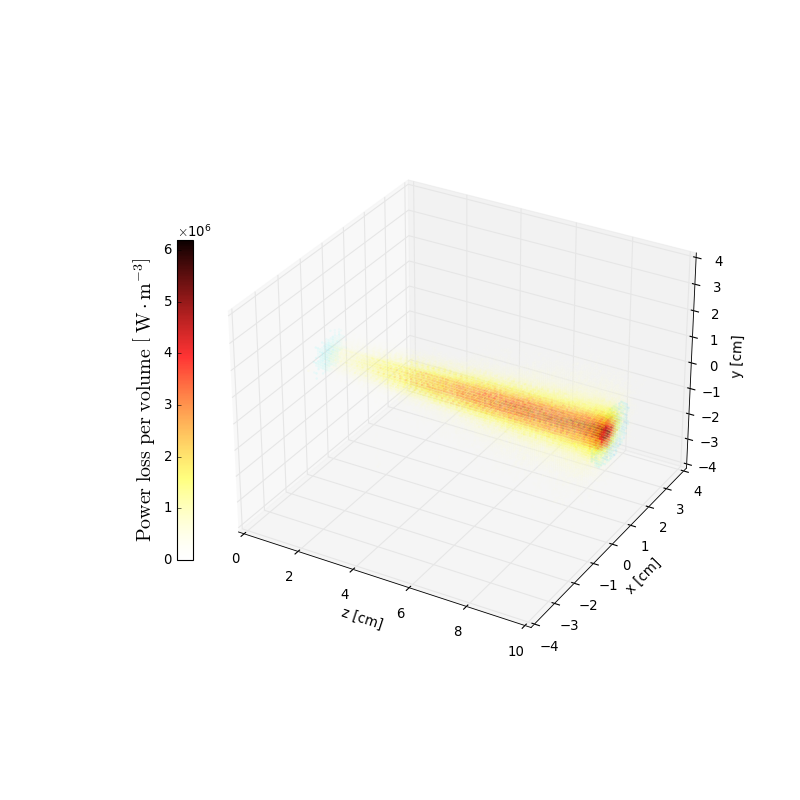

In [12]:
X,Y = np.meshgrid(np.unique(df_LXe['x']), np.unique(df_LXe['y']))

plt.close()
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10,10))
img = ax.scatter(df_LXe['z'], df_LXe['x'], df_LXe['y'], c=df_LXe['EDD'], marker='o', s=5, cmap='hot_rT', edgecolors='none')
ax.scatter(df_Entrance['z'], df_Entrance['x'], df_Entrance['y'], c=df_Entrance['EDD'], marker='o', s=5, cmap='coolT', edgecolors='none', vmax = 6e6)
ax.scatter(df_Exit['z'], df_Exit['x'], df_Exit['y'], c=df_Exit['EDD'], marker='o', s=5, cmap='coolT', edgecolors='none', vmax = 6e6)

cb = fig.colorbar(img, ax=ax, pad=0.01, shrink=.5, location='left')
cb.set_label(label=r'$\mathrm{Power\ loss\ per\ volume}\ \left[\ \mathrm{W}\cdot \mathrm{m}^{-3}\right]$', fontsize=18)
cb.formatter.set_useMathText(True)
cb.formatter.set_powerlimits((0, 0))

ax.set_xlabel('z [cm]')
ax.set_ylabel('x [cm]')
ax.set_zlabel('y [cm]')

ax.set_xlim(0, 10)

plt.show()

# Export data

In [21]:
df_LXe.to_csv(path+"/Silviu_LXe.csv", index=False)
df_Entrance.to_csv(path+"/Silviu_entrance_window.csv", index=False)
df_Exit.to_csv(path+"/Silviu_exit_window.csv", index=False)